# Инжиниринг численных признаков

In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
prsa_data = pd.read_csv("data/PRSA_Data.csv")
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,-1.0,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,-1.0,-1.000000,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,-1.0,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


In [110]:
prsa_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  35064 non-null  int64  
 1   No          35064 non-null  int64  
 2   SO2         35064 non-null  float64
 3   NO2         35064 non-null  float64
 4   CO          35064 non-null  float64
 5   O3          35064 non-null  float64
 6   PRES        35064 non-null  float64
 7   RAIN        35064 non-null  float64
 8   wd          35064 non-null  str    
 9   WSPM        35064 non-null  float64
 10  AQI Label   35064 non-null  str    
dtypes: float64(7), int64(2), str(2)
memory usage: 2.9 MB


In [111]:
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,WSPM
count,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000,35064.000000
mean,17531.500000,17532.500000,18.058734,63.236861,1251.121692,45.876835,1010.520250,0.067653,1.500217
std,10122.249256,10122.249256,22.558126,39.109232,1269.033556,54.730861,26.289217,0.896833,1.105382
min,0.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,8765.750000,8766.750000,4.000000,34.000000,500.000000,2.397428,1002.500000,0.000000,0.800000
50%,17531.500000,17532.500000,10.000000,58.000000,900.000000,27.356346,1010.800000,0.000000,1.200000
75%,26297.250000,26298.250000,22.276800,87.000000,1500.000000,69.548316,1019.400000,0.000000,2.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,72.500000,11.200000


In [112]:
prsa_data[prsa_data == -1] = np.nan
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,RAIN,wd,WSPM,AQI Label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,0.0,NNW,4.4,Severely Polluted
1,1,2,6.0,28.0,400.0,50.403851,1023.2,0.0,N,4.7,Severely Polluted
2,2,3,NaN,19.0,400.0,54.923321,1023.5,0.0,NNW,5.6,Severely Polluted
3,3,4,8.0,14.0,NaN,NaN,1024.5,0.0,NW,3.1,Excellent
4,4,5,9.0,NaN,300.0,54.296608,1025.2,0.0,N,2.0,Heavily Polluted


<Axes: xlabel='SO2', ylabel='Count'>

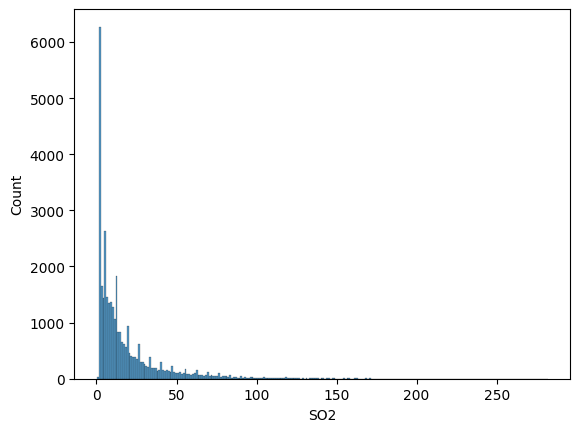

In [113]:
sns.histplot(prsa_data.SO2)

<Axes: xlabel='NO2', ylabel='Density'>

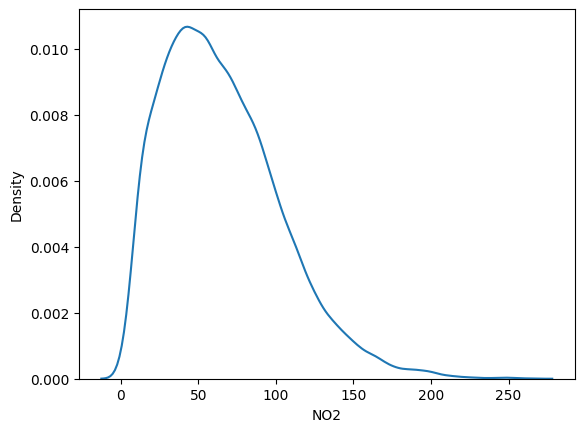

In [114]:
sns.kdeplot(prsa_data.NO2)

<Axes: xlabel='CO', ylabel='Count'>

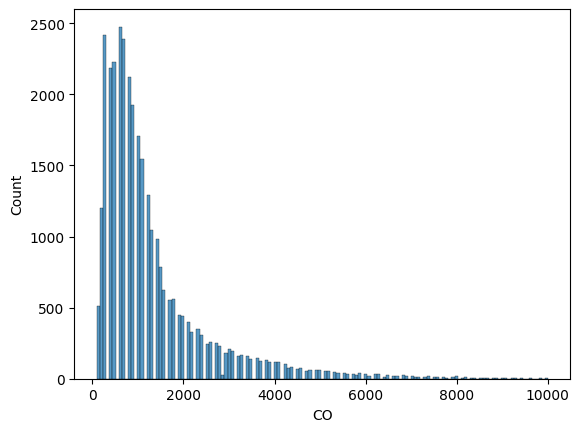

In [115]:
sns.histplot(prsa_data.CO)

<Axes: xlabel='O3', ylabel='Count'>

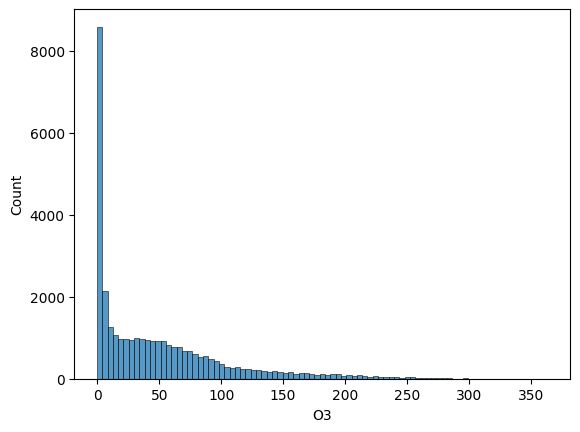

In [116]:
sns.histplot(prsa_data.O3)

<Axes: xlabel='PRES', ylabel='Count'>

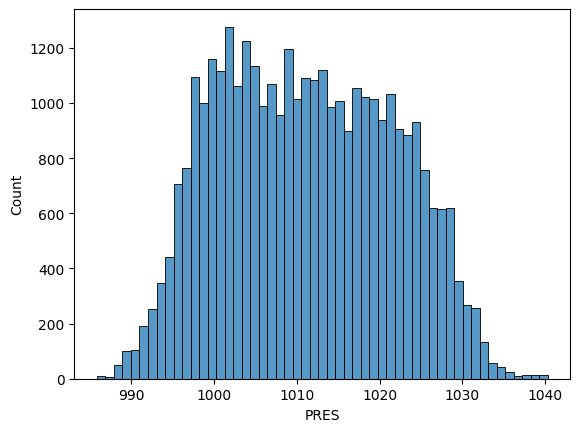

In [117]:
sns.histplot(prsa_data.PRES)

<Axes: xlabel='RAIN', ylabel='Count'>

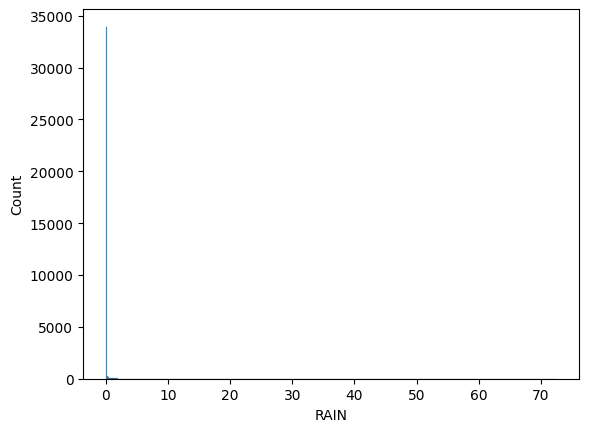

In [118]:
sns.histplot(prsa_data.RAIN)

In [119]:
prsa_data.RAIN[prsa_data.RAIN > 0]

267      0.1
268      0.4
269      0.1
270      0.9
271      0.9
        ... 
34891    0.2
34892    0.7
34893    0.9
34894    0.4
34895    0.2
Name: RAIN, Length: 1436, dtype: float64

In [120]:
is_rain = np.array(prsa_data.RAIN)
is_rain[is_rain > 0] = 1
prsa_data['IS_RAIN'] = is_rain
prsa_data.drop(['RAIN'], axis=1, inplace=True)
prsa_data.describe()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,WSPM,IS_RAIN
count,35064.000000,35064.000000,34489.000000,33994.000000,33252.000000,32957.000000,35044.000000,35050.000000,35044.000000
mean,17531.500000,17532.500000,18.376481,65.258789,1319.353513,48.873754,1011.097536,1.501215,0.040977
std,10122.249256,10122.249256,22.609648,37.996088,1268.114331,55.113576,10.355247,1.104472,0.198240
min,0.000000,1.000000,0.285600,1.642400,100.000000,-0.275160,985.900000,0.000000,0.000000
25%,8765.750000,8766.750000,4.000000,36.000000,500.000000,3.579219,1002.500000,0.800000,0.000000
50%,17531.500000,17532.500000,10.000000,60.000000,900.000000,31.945652,1010.800000,1.200000,0.000000
75%,26297.250000,26298.250000,23.000000,88.000000,1600.000000,72.876079,1019.400000,2.000000,0.000000
max,35063.000000,35064.000000,282.000000,264.000000,10000.000000,363.769133,1040.300000,11.200000,1.000000


<Axes: xlabel='SO2', ylabel='Density'>

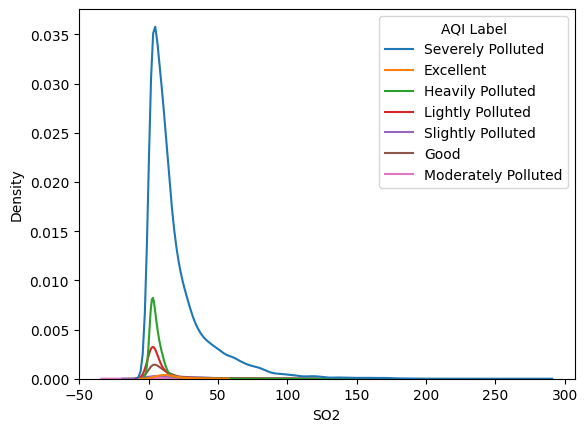

In [121]:
sns.kdeplot(data=prsa_data, x="SO2", hue="AQI Label")

<Axes: xlabel='NO2', ylabel='Density'>

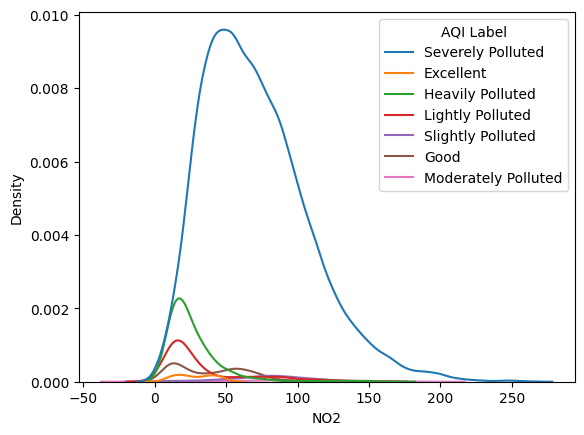

In [122]:
sns.kdeplot(data=prsa_data, x="NO2", hue="AQI Label")

C:\Users\vadve\AppData\Local\Temp\ipykernel_38808\491964310.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")


<Axes: xlabel='CO', ylabel='Density'>

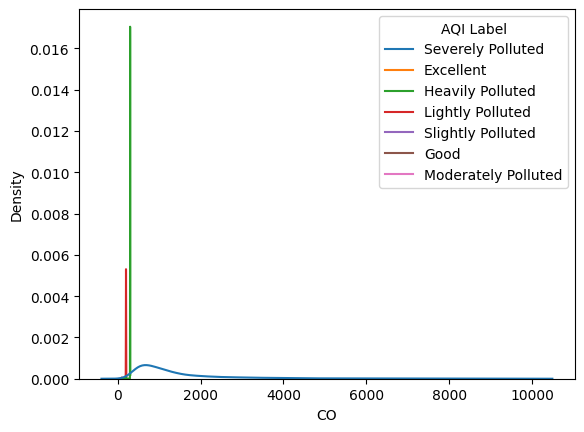

In [123]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label")

C:\Users\vadve\AppData\Local\Temp\ipykernel_38808\2756761127.py:1: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)


<Axes: xlabel='CO', ylabel='Density'>

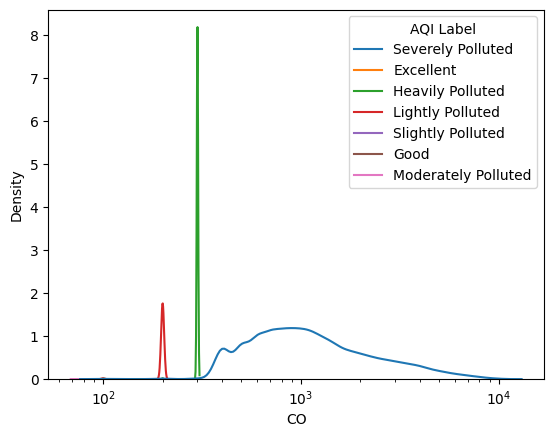

In [124]:
sns.kdeplot(data=prsa_data, x="CO", hue="AQI Label", log_scale=True)

In [125]:
bin_ranges = [0, 250, 320, 10000]
bin_names = [1, 2, 3]
prsa_data['CO_bin_custom_label'] = pd.cut(np.array(prsa_data['CO']), 
                                               bins=bin_ranges, labels=bin_names)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,NaN
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


In [126]:
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].values.add_categories(0)
prsa_data['CO_bin_custom_label'] = prsa_data['CO_bin_custom_label'].fillna(0).astype(int)
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.0,28.0,400.0,51.577659,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.0,28.0,400.0,50.403851,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,NaN,19.0,400.0,54.923321,1023.5,NNW,5.6,Severely Polluted,0.0,3
3,3,4,8.0,14.0,NaN,NaN,1024.5,NW,3.1,Excellent,0.0,0
4,4,5,9.0,NaN,300.0,54.296608,1025.2,N,2.0,Heavily Polluted,0.0,2


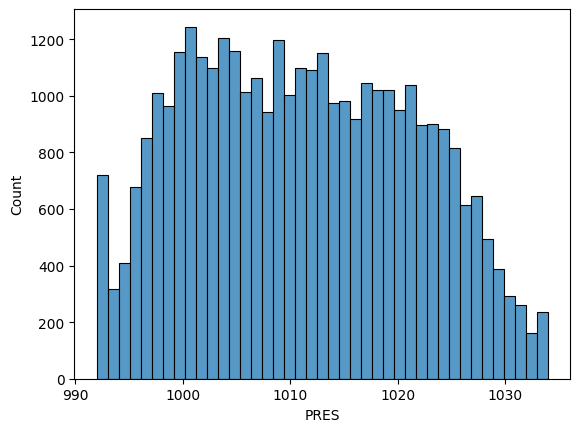

In [127]:
prsa_data.loc[prsa_data["PRES"] <= 992, "PRES"] = 992
prsa_data.loc[prsa_data["PRES"] >= 1034, "PRES"] = 1034
sns.histplot(prsa_data.PRES)
plt.show()

<Axes: >

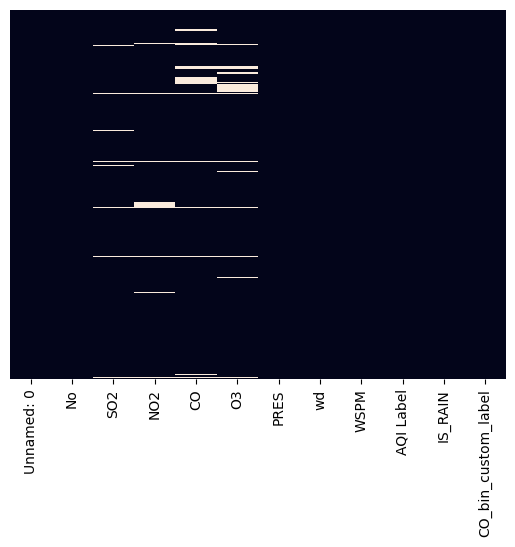

In [128]:
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [129]:
undef = prsa_data.isnull().sum(axis=1)
undef[undef >= 2]

3        2
276      3
435      2
459      2
555      2
        ..
34880    4
34883    4
34885    4
35029    2
35030    2
Length: 884, dtype: int64

<Axes: >

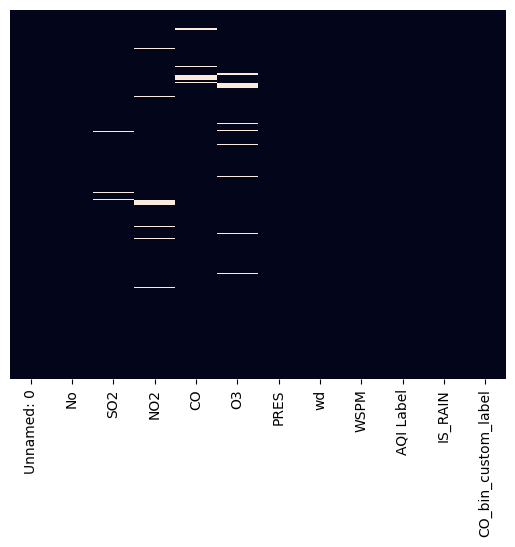

In [130]:
prsa_data = prsa_data.drop(undef[undef >= 2].index, axis=0)
sns.heatmap(prsa_data.isnull(), yticklabels=False, cbar=False)

In [131]:
prsa_data.isnull().sum()

Unnamed: 0                0
No                        0
SO2                     281
NO2                     702
CO                     1028
O3                     1300
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
dtype: int64

<Axes: xlabel='SO2', ylabel='Count'>

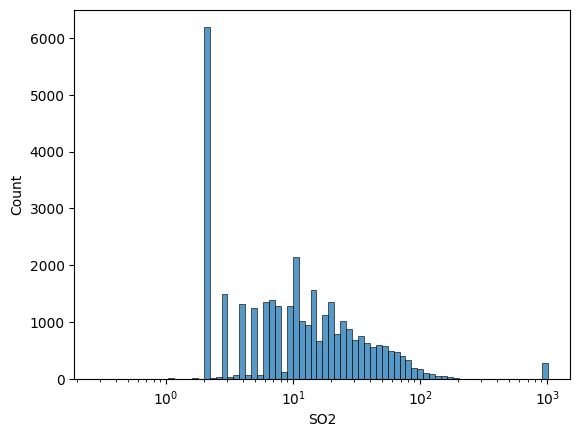

In [132]:
prsa_data.SO2 = prsa_data.SO2.fillna(prsa_data.PRES.mean())
sns.histplot(prsa_data.SO2, log_scale=True)

In [133]:
filler = prsa_data.O3[prsa_data.O3.isna()]
filler = prsa_data.O3[~prsa_data.O3.isna()].sample(n=len(filler)).set_axis(filler.index)
filler

436       88.866539
460      102.782328
556        2.981638
652       30.429621
748        1.293680
            ...    
33124      2.156147
33220     56.487493
33604      1.942363
33892     17.598008
35031     18.269858
Name: O3, Length: 1300, dtype: float64

In [134]:
prsa_data.O3 = prsa_data.O3.fillna(filler)
filler.sum() == prsa_data.O3.sum()

np.False_

<Axes: xlabel='O3', ylabel='Count'>

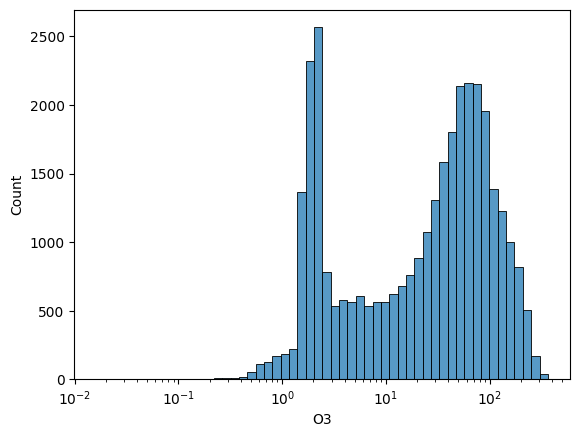

In [135]:
sns.histplot(prsa_data.O3, log_scale=True)

In [136]:
prsa_data['O3'] = np.array(np.round((prsa_data['O3'])), dtype='int')
prsa_data.head()

,Unnamed: 0,No,SO2,NO2,CO,O3,PRES,wd,WSPM,AQI Label,IS_RAIN,CO_bin_custom_label
0,0,1,6.000000,28.0,400.0,52,1023.0,NNW,4.4,Severely Polluted,0.0,3
1,1,2,6.000000,28.0,400.0,50,1023.2,N,4.7,Severely Polluted,0.0,3
2,2,3,1011.055986,19.0,400.0,55,1023.5,NNW,5.6,Severely Polluted,0.0,3
4,4,5,9.000000,NaN,300.0,54,1025.2,N,2.0,Heavily Polluted,0.0,2
5,5,6,8.000000,17.0,300.0,54,1025.6,N,3.7,Heavily Polluted,0.0,2


<Axes: xlabel='SO2', ylabel='Count'>

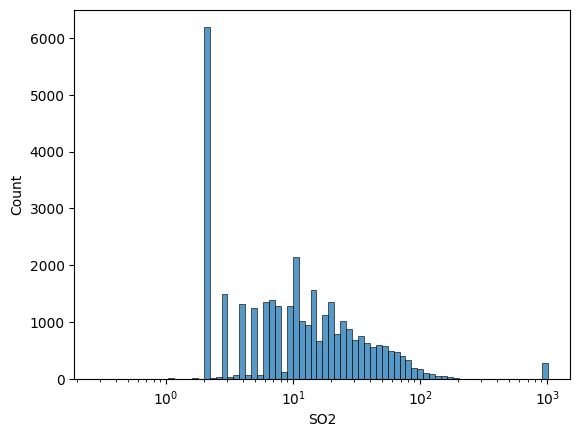

In [137]:
sns.histplot(prsa_data.SO2, log_scale=True)

<Axes: xlabel='SO2', ylabel='Count'>

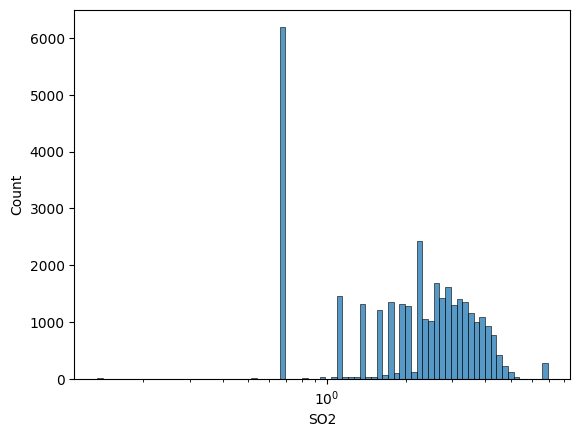

In [138]:
prsa_data.SO2 = np.log(prsa_data.SO2)
sns.histplot(prsa_data.SO2, log_scale=True)

## Задания для самостоятельного выполнения

#### 1. При выполнении 3 и 5 заданий используйте другие методы визуализации. Найдите самый подходящий тип графика для каждого распределения.

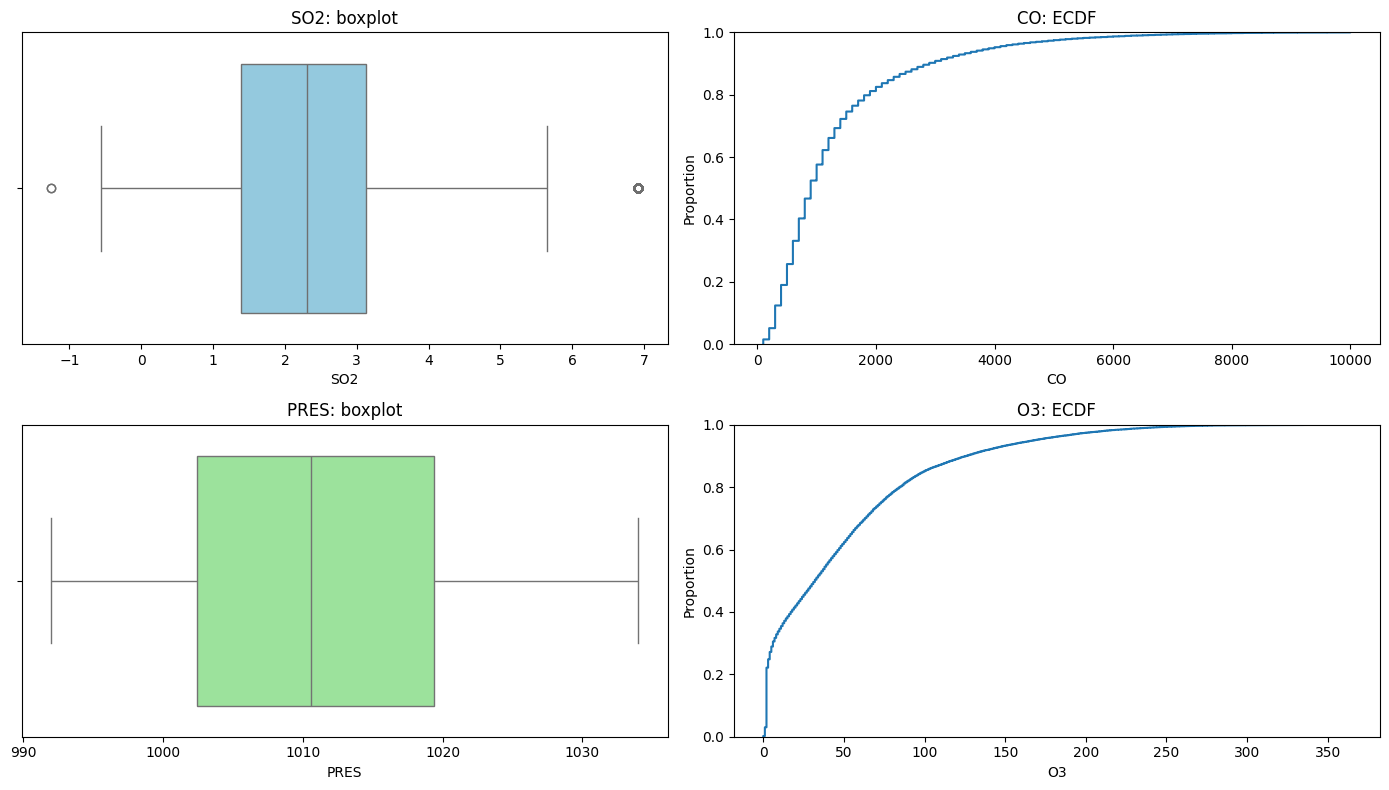

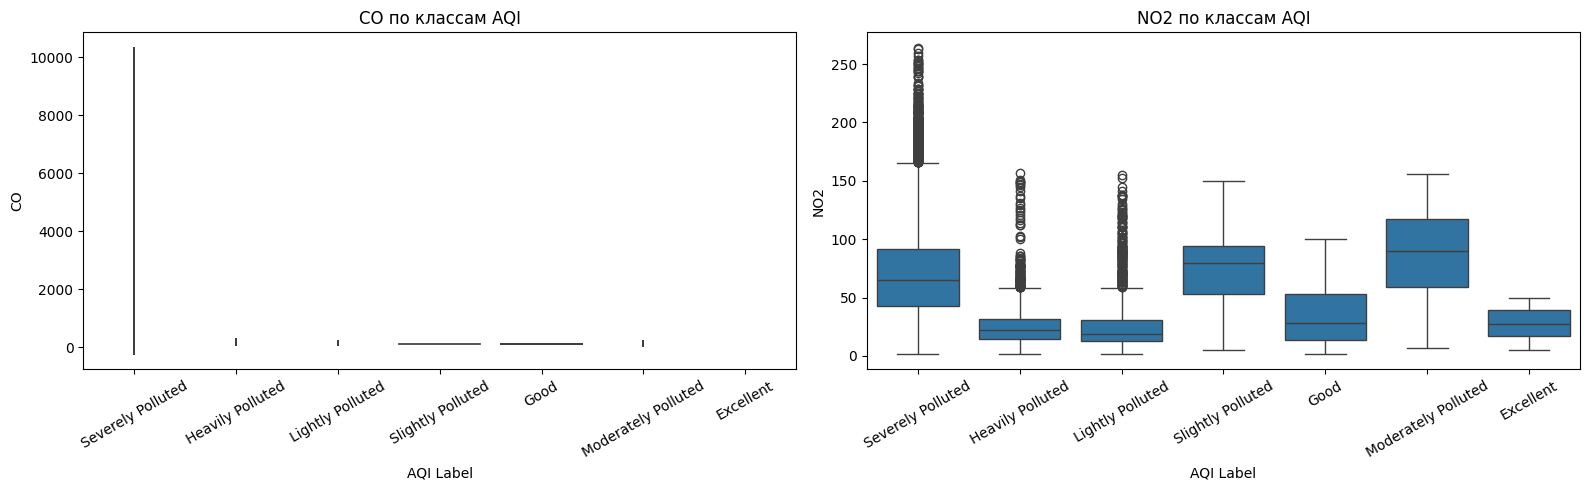

In [139]:
numeric_cols = ["SO2", "NO2", "CO", "O3", "PRES", "WSPM", "IS_RAIN", "CO_bin_custom_label"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

sns.boxplot(x=prsa_data["SO2"], ax=axes[0, 0], color="skyblue")
axes[0, 0].set_title("SO2: boxplot")

sns.ecdfplot(prsa_data["CO"].dropna(), ax=axes[0, 1])
axes[0, 1].set_title("CO: ECDF")

sns.boxplot(x=prsa_data["PRES"], ax=axes[1, 0], color="lightgreen")
axes[1, 0].set_title("PRES: boxplot")

sns.ecdfplot(prsa_data["O3"].dropna(), ax=axes[1, 1])
axes[1, 1].set_title("O3: ECDF")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.violinplot(data=prsa_data, x="AQI Label", y="CO", ax=axes[0], inner="quartile")
axes[0].set_title("CO по классам AQI")
axes[0].tick_params(axis="x", rotation=30)

sns.boxplot(data=prsa_data, x="AQI Label", y="NO2", ax=axes[1])
axes[1].set_title("NO2 по классам AQI")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

#### 2. При выполнении 6 задания мы явно подбирали руками границы диапазона для клиппинга. Реализуйте адаптивный клиппинг через процентили.

Границы клиппинга PRES: [992.00, 1032.00]


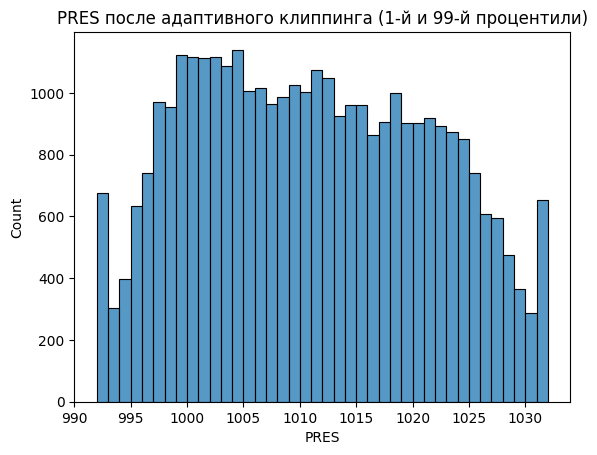

In [140]:
low_q, high_q = prsa_data["PRES"].quantile([0.01, 0.99])
print(f"Границы клиппинга PRES: [{low_q:.2f}, {high_q:.2f}]")

prsa_data["PRES"] = prsa_data["PRES"].clip(lower=low_q, upper=high_q)
sns.histplot(prsa_data["PRES"], bins=40)
plt.title("PRES после адаптивного клиппинга (1-й и 99-й процентили)")
plt.show()

#### 3. Избавьтесь от оставшихся пропусков в данных. Самостоятельно выберите метод.

In [141]:
print("Пропуски до заполнения:")
print(prsa_data.isnull().sum())

prsa_data = prsa_data.replace([np.inf, -np.inf], np.nan)

for col in ["SO2", "NO2", "CO"]:
    prsa_data[col] = prsa_data[col].fillna(
        prsa_data.groupby("AQI Label")[col].transform("median")
    )
    prsa_data[col] = prsa_data[col].fillna(prsa_data[col].median())

print("\nПропуски после заполнения:")
print(prsa_data.isnull().sum())

Пропуски до заполнения:
Unnamed: 0                0
No                        0
SO2                       0
NO2                     702
CO                     1028
O3                        0
PRES                      0
wd                        0
WSPM                      0
AQI Label                 0
IS_RAIN                   0
CO_bin_custom_label       0
dtype: int64

Пропуски после заполнения:
Unnamed: 0             0
No                     0
SO2                    0
NO2                    0
CO                     0
O3                     0
PRES                   0
wd                     0
WSPM                   0
AQI Label              0
IS_RAIN                0
CO_bin_custom_label    0
dtype: int64


#### 4. Проведите нормализацию численных признаков. Выберите наиболее подходящий вид нормализации для каждого признака.

In [142]:
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

prsa_data_norm = prsa_data.copy()
prsa_data_norm = prsa_data_norm.replace([np.inf, -np.inf], np.nan)

num_cols = prsa_data_norm.select_dtypes(include=[np.number]).columns
for col in num_cols:
    prsa_data_norm[col] = prsa_data_norm[col].fillna(prsa_data_norm[col].median())

standard_cols = ["NO2", "PRES", "WSPM"]
prsa_data_norm[standard_cols] = StandardScaler().fit_transform(prsa_data_norm[standard_cols])

robust_cols = ["SO2", "CO", "O3"]
prsa_data_norm[robust_cols] = RobustScaler().fit_transform(prsa_data_norm[robust_cols])

minmax_cols = ["IS_RAIN", "CO_bin_custom_label"]
prsa_data_norm[minmax_cols] = MinMaxScaler().fit_transform(prsa_data_norm[minmax_cols])

print("Статистика нормализованных признаков:")
display(prsa_data_norm[standard_cols + robust_cols + minmax_cols].describe().T)

Статистика нормализованных признаков:

,count,mean,std,min,25%,50%,75%,max
NO2,34180.0,3.991346e-17,1.000015,-1.672697,-0.763001,-0.127546,0.587340,5.273818
PRES,34180.0,-1.138864e-14,1.000015,-1.848825,-0.839159,-0.043076,0.811258,2.034508
WSPM,34180.0,1.130881e-16,1.000015,-1.363122,-0.640779,-0.189314,0.442736,8.749685
SO2,34180.0,2.028006e-02,0.683147,-2.032786,-0.523834,0.000000,0.476166,2.639015
CO,34180.0,3.903963e-01,1.261719,-0.800000,-0.400000,0.000000,0.600000,9.100000
O3,34180.0,2.453833e-01,0.799339,-0.463768,-0.405797,0.000000,0.594203,4.811594
IS_RAIN,34180.0,4.154476e-02,0.199549,0.000000,0.000000,0.000000,0.000000,1.000000
CO_bin_custom_label,34180.0,9.131071e-01,0.229283,0.000000,1.000000,1.000000,1.000000,1.000000


#### 5. Постройте кореллограмму по всем численным столбцам датасета. Сделайте вывод о значимости признаков.

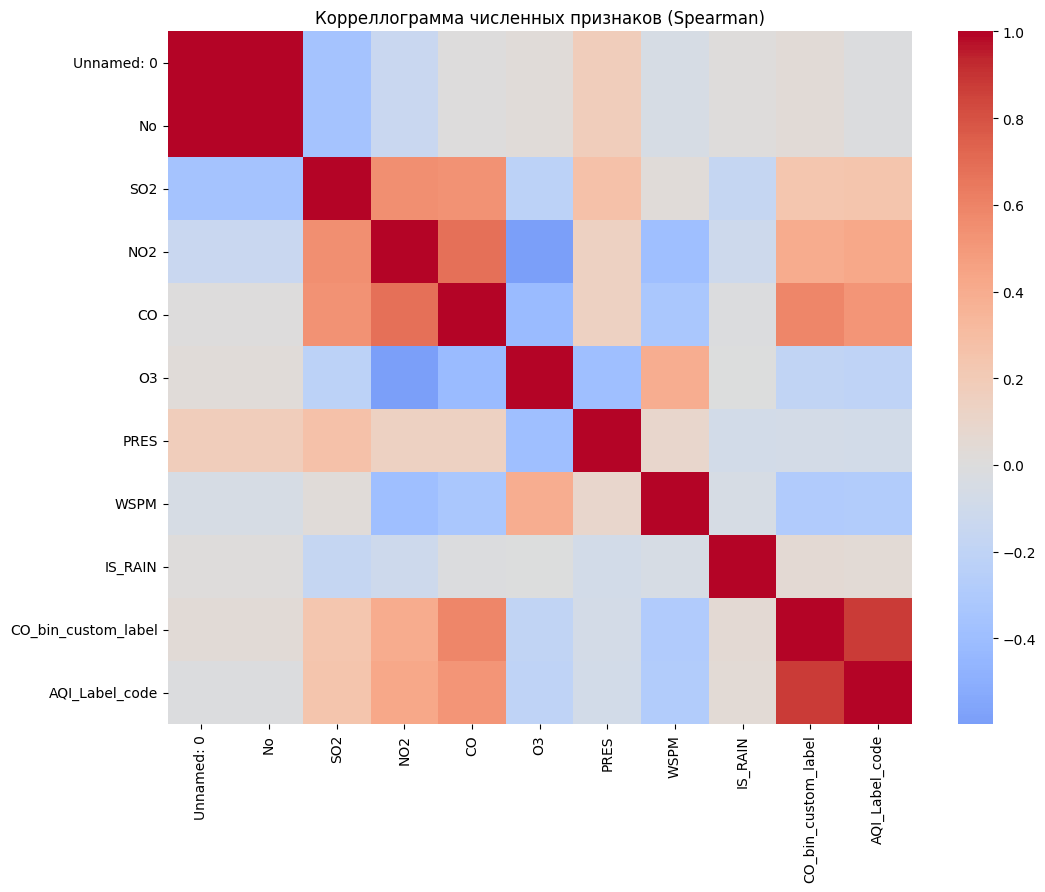

лучшие признаки по модулю корреляции с целевой переменной:
CO_bin_custom_label    0.875124
CO                     0.518923
NO2                    0.425805
WSPM                   0.282865
SO2                    0.250292
Name: AQI_Label_code, dtype: float64


In [143]:
numeric_df = prsa_data.select_dtypes(include=[np.number]).copy()

numeric_df["AQI_Label_code"] = pd.Categorical(prsa_data["AQI Label"]).codes

corr_matrix = numeric_df.corr(method="spearman")

plt.figure(figsize=(12, 9))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, annot=False)
plt.title("Корреллограмма численных признаков (Spearman)")
plt.show()

target_corr = corr_matrix["AQI_Label_code"].drop("AQI_Label_code").abs().sort_values(ascending=False)
print("лучшие признаки по модулю корреляции с целевой переменной:")
print(target_corr.head(5))

#### 6. Визуализируйте связи между признаками. Сделайте вывод об их взаимозависимости.

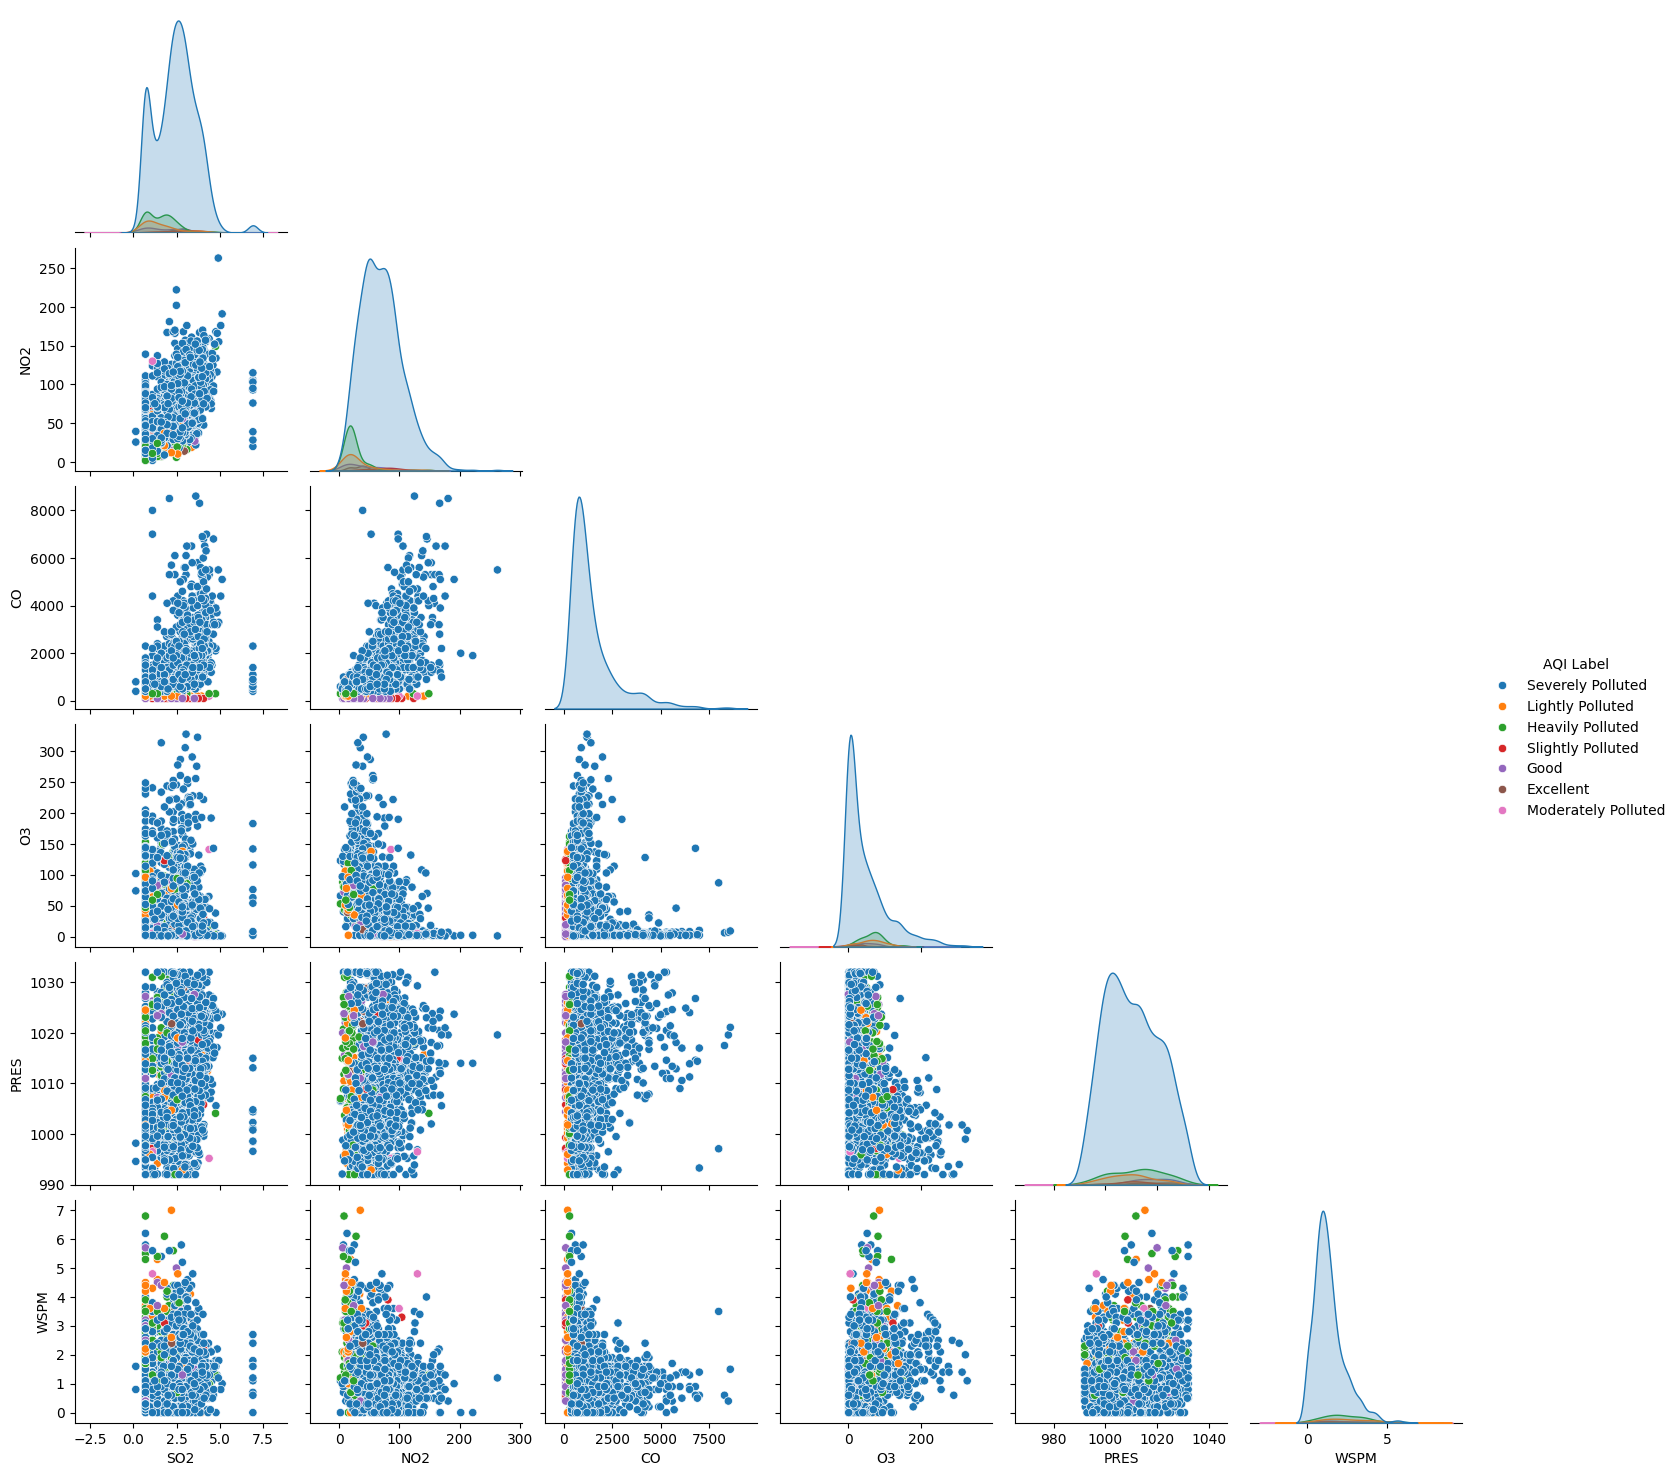

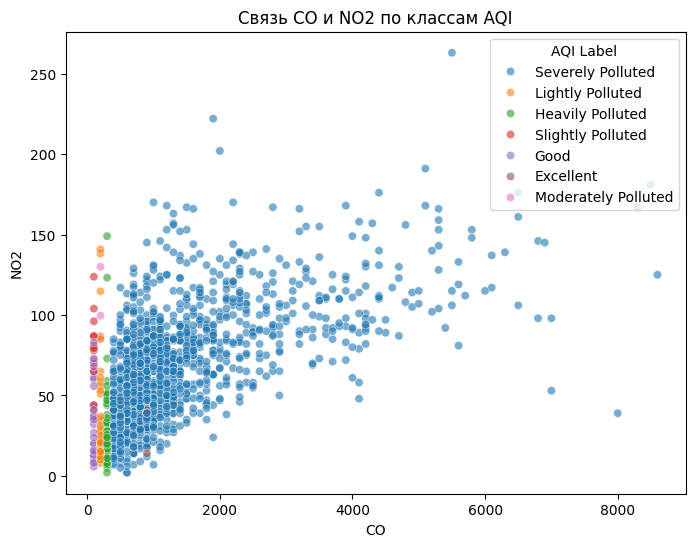

In [144]:
selected = ["SO2", "NO2", "CO", "O3", "PRES", "WSPM", "AQI Label"]

sample_df = prsa_data[selected].dropna().sample(n=1500, random_state=42)
sns.pairplot(sample_df, hue="AQI Label", corner=True, diag_kind="kde")
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=sample_df, x="CO", y="NO2", hue="AQI Label", alpha=0.6)
plt.title("Связь CO и NO2 по классам AQI")
plt.show()

# между газовыми признаками (CO, NO2, SO2) видна заметная взаимосвязь
# классы AQI частично разделяются в пространстве признаков